In [12]:
import sys
sys.path.append('../')


from tqdm import tqdm
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from sympy import symbols
import utils_2Q_gate_zp as ut
import sigmaX_fidelity_optimize as zpX
import qutip as qt
import scqubits as scq
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy as sp
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed
from IPython.display import display, Math

import networkx as nx

# Initialize Hilbert Space

In [48]:
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)

phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 200)
trunc1 = 500
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=40, truncated_dim=trunc1)
n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=trunc1)
n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=trunc1)
n_Phi = 2*np.pi * qt.Qobj(n_phi)
n_Theta = 2*np.pi * qt.Qobj(n_theta)

evals = 2*np.pi * zero_pi.eigenvals(evals_count=trunc1)
evals = evals-evals[0]
H0 = qt.Qobj(np.diag(evals))

w_trans_1 = {}
w_trans_2 = {}
core_states = {}
drive_term = {}

w_trans_1["phi"] = evals[9] - evals[0]
w_trans_2["phi"] = evals[9] - evals[2]
drive_term["phi"] = n_Phi
core_states["phi"] = [0, 2, 9]

w_trans_1["theta"] = evals[7] - evals[0]
w_trans_2["theta"] = evals[7] - evals[2]
drive_term["theta"] = n_Theta
core_states["theta"] = [0, 2, 7]

# Truncation Estimate

To estimate which transitions should be the most important, we can calculate a generalized rabi frequency for each transition

$$
\Omega_{ij} = \frac{(A n_{ij})^2}{(A n_{ij})^2 + \delta^2}
$$

where $A$ is the amplitude of the control pulse and $n_{ij} = \langle i | n | j \rangle$ is the drive matrix. $\delta$ is the detuning between the drive and the transition $\omega_d - \omega_{ij}$.

Other leakage estimate (not using):

$$
\frac{1}{1 + \lambda e^{-\delta^2 \tau^2}}
$$


In [49]:
drives = ["phi", "theta"]
rabi_df = {}
rabi_freq = {}
A = 1
tau = 1
for drive in drives:
    # Normalize based on n
    ######
    max_n_ij = np.max(np.abs(drive_term[drive].full()))
    ######
    rabi_freq[drive] = np.zeros((evals.size, evals.size, 2))
    rabi_df[drive] = []
    n1 = np.abs(drive_term[drive][core_states[drive][0], core_states[drive][-1]])
    n2 = np.abs(drive_term[drive][core_states[drive][1], core_states[drive][-1]])
    for i in range(trunc1):
        for j in range(trunc1):
            if i >= j:
                continue
            n_ij = np.abs(drive_term[drive][i, j])
            normalization =  n_ij/max_n_ij
            # Assume very close to resonance driving -- not actually true
            detune = -0.001
            delta1 = abs(abs(w_trans_1[drive]) - abs(evals[i] - evals[j]) - detune)
            delta2 = abs(abs(w_trans_2[drive]) - abs(evals[i] - evals[j]) - detune)
            if delta1 < delta2:
                delta = delta1
                # normalization = n_ij/n1
            else:
                delta = delta2
                # normalization = n_ij/n2
            # Omega_ij = 1-1/(1+normalization*np.exp((-delta**2)*(tau**2)))
            # rabi_freq[drive][i, j] = normalization*Omega_ij
            Omega_ij = ((A*n_ij)**2) / ((A*n_ij)**2 + delta**2)
            n_ij = normalization*n_ij
            Omega_ij_norm = ((A*n_ij)**2) / ((A*n_ij)**2 + delta**2)
            rabi_freq[drive][i, j, 0] = Omega_ij
            rabi_freq[drive][i, j, 1] = Omega_ij_norm
        rabi_df[drive].append({"i": i, "E": evals[i]})
    rabi_df[drive] = pd.DataFrame(rabi_df[drive])
    rabi_df[drive].index = rabi_df[drive]["i"]

Now for each transition we can calculate a "distance" from the states used in the gate (i.e. logical + intermediate). Here we define this distance as the product of the rabi frequencies of transitions that get you there. To calculate the distance, construct a graph where the nodes are the basis states and the weights on each edge are:

$$
W_{ij} = -\log(\Omega_{ij})
$$

Note that the edge is only added if $\Omega_{ij} > 0$. We can then use graph search algorithms to find the shortest path, or distance from any state to the states that will be intentionally populated during the gate. This will form the basis for deciding which transitions/states are most important.

In [50]:
# Construct the graph
rabi_graph = {}
for drive in drives:
    rabi_graph[drive] = nx.Graph()
    for i in range(trunc1):
        for j in range(trunc1):
            if i >= j:
                continue
            Omega_ij = rabi_freq[drive][i,j, 0]
            Omega_ij_norm = rabi_freq[drive][i,j, 1]
            if Omega_ij > 0:
                rabi_graph[drive].add_edge(i, j, weight=-np.log(Omega_ij), weight_norm=-np.log(Omega_ij_norm))  # specify edge data

In [51]:
def shortest_path_to_core(args):
    target, drive = args
    shortest_path = ""
    shortest_path_len = np.inf
    for source in core_states[drive][:-1]:
        path = nx.shortest_path(rabi_graph[drive],
                                source=source, target=target,
                                weight="weight_norm")
        path_len = nx.path_weight(rabi_graph[drive], path,
                                  weight="weight_norm")          
        # nx.shortest_path_length(rabi_graph[drive],
        #                                     source=source, target=target,
        #                                     weight="weight")
        # Only consider paths where the last two in the path are
        # the states being considered in this transition
        # if i in path[-2:] and j in path[-2:] and path_len < shortest_path_len:
        if path_len < shortest_path_len:
            shortest_path_len = path_len
            shortest_path = ",".join([str(x) for x in path])
    return args, (shortest_path_len, shortest_path)

# Find shortest path for each node
from multiprocessing import Pool
pool = Pool(processes=150)
shortest_path = {}
for drive in ["theta", "phi"]:
    vals = [(i, drive) for i in range(trunc1)]
    shortest_path[drive] = {}
    # Add columns to rabi_df
    rabi_df[drive]["path"] = ""
    rabi_df[drive]["max_mat_elem"] = 0.0
    rabi_df[drive]["path_len"] = 0.0
    rabi_df[drive]["path_len_rabi"] = 0.0
    rabi_df[drive]["degree"] = -1
    rabi_df[drive]["first_leakage"] = -1
    for idx, path in tqdm(pool.imap_unordered(shortest_path_to_core, vals),
                    total=sum(1 for _ in vals)):
        shortest_path[drive][idx[0]] = path

        rabi_df[drive].at[idx[0], "path"] = path[1]
        rabi_df[drive].at[idx[0], "path_len"] = np.exp(-path[0])
        path_list = [int(i) for i in path[1].split(",")]
        rabi_df[drive].at[idx[0], "path_len_rabi"] = np.exp(-nx.path_weight(rabi_graph[drive], path_list, weight="weight"))
        rabi_df[drive].at[idx[0], "degree"] = path[1].count(",")
        rabi_df[drive].at[idx[0], "max_mat_elem"] = max([np.abs(drive_term[drive][s, idx[0]]/(2*np.pi)) for s in core_states[drive]])
        leakage_states = [int(x) for x in path[1].split(",") if int(x) not in core_states[drive]]
        if leakage_states:
            rabi_df[drive].at[idx[0], "first_leakage"] = leakage_states[0]
        else:
            rabi_df[drive].at[idx[0], "first_leakage"] = -1

100%|██████████| 500/500 [00:00<00:00, 1438.02it/s]


## $n_\theta$

In [52]:
rabi_df["theta"].sort_values("path_len", ascending=False).iloc[:30]

,i,E,path,max_mat_elem,path_len,path_len_rabi,degree,first_leakage
i,,,,,,,,
0,0,0.000000,0,0.052244,1.000000e+00,1.000000,0,-1
2,2,21.378684,2,0.190835,1.000000e+00,1.000000,0,-1
7,7,43.872917,"2,7",0.190835,9.971129e-01,0.999999,1,-1
4,4,30.444609,"2,7,4",1.996356,4.776446e-02,0.656815,2,4
11,11,58.110129,"2,7,11",1.547078,2.134470e-02,0.580815,2,11
1,1,15.753235,"0,1",1.304416,1.631510e-02,0.596416,1,1
5,5,36.432909,"2,5",1.261868,1.178394e-02,0.531689,1,5
8,8,49.052483,"2,7,8",1.681005,6.867318e-03,0.271172,2,8
12,12,61.379761,"2,7,11,12",0.098815,1.290281e-03,0.293381,3,11


First leakage states

In [53]:
first_leak = {}
first_leak["theta"] = [x for x in rabi_df["theta"]["first_leakage"].iloc[:150].unique() if x != -1]
sorted(first_leak["theta"])

[1, 4, 5, 6, 8, 10, 11, 16, 18, 25]

States to include

## $n_\phi$

In [54]:
rabi_df["phi"].sort_values(by="path_len", ascending=False).iloc[:30]

,i,E,path,max_mat_elem,path_len,path_len_rabi,degree,first_leakage
i,,,,,,,,
0,0,0.000000,0,0.048825,1.000000,1.000000,0,-1
2,2,21.378684,2,0.019738,1.000000,1.000000,0,-1
9,9,50.893867,"0,9",0.048825,0.983871,0.999989,1,-1
33,33,101.341312,"0,9,33",0.304276,0.309821,0.948064,2,33
55,55,130.898492,"0,9,33,55",0.034304,0.241740,0.946355,3,33
69,69,151.974837,"0,9,33,69",0.031168,0.235877,0.936689,3,33
92,92,181.774064,"0,9,33,69,92",0.019033,0.168057,0.922917,4,33
76,76,157.939525,"0,9,33,55,76",0.020694,0.115278,0.778798,4,33
10,10,57.284586,"0,10",0.688718,0.055850,0.314433,1,10


In [55]:
first_leak["phi"] = [x for x in rabi_df["phi"]["first_leakage"].unique() if x != -1]
sorted(first_leak["phi"])

[10, 11, 19, 33]

# Estimating if We've Included Enough States

To estimate whether we've included enough states or not, consider the highest energy state that we've included (i.e. 300th energy) and see what the frequency difference between that state and any other state we think might participate strongly. We can then use a simialar estimate of of what fraction of population would transfer, assuming $A=1$ and $n_{ij}$ being the maximum in the row of question.

$$
\Omega_{ij} = \frac{(A n_{ij})^2}{(A n_{ij})^2 + \delta^2}
$$

Could also drive and see what the highest state populated above a certain amount is

In [58]:
Emax = evals[-1]
Emax

480.32649753519655

In [59]:
rabi_df["theta"][np.logical_and(rabi_df["theta"].degree<=3, rabi_df["theta"]["path_len_rabi"] >= 1e-08)]

,i,E,path,max_mat_elem,path_len,path_len_rabi,degree,first_leakage
i,,,,,,,,
0,0,0.000000,0,0.052244,1.000000e+00,1.000000e+00,0,-1
1,1,15.753235,"0,1",1.304416,1.631510e-02,5.964156e-01,1,1
2,2,21.378684,2,0.190835,1.000000e+00,1.000000e+00,0,-1
4,4,30.444609,"2,7,4",1.996356,4.776446e-02,6.568151e-01,2,4
5,5,36.432909,"2,5",1.261868,1.178394e-02,5.316893e-01,1,5
7,7,43.872917,"2,7",0.190835,9.971129e-01,9.999993e-01,1,-1
8,8,49.052483,"2,7,8",1.681005,6.867318e-03,2.711715e-01,2,8
11,11,58.110129,"2,7,11",1.547078,2.134470e-02,5.808145e-01,2,11
12,12,61.379761,"2,7,11,12",0.098815,1.290281e-03,2.933806e-01,3,11


In [65]:
to_check = rabi_df["theta"][np.logical_and(rabi_df["theta"].degree<=3, rabi_df["theta"]["path_len_rabi"] >= 1e-07)]
to_check

,i,E,path,max_mat_elem,path_len,path_len_rabi,degree,first_leakage
i,,,,,,,,
0,0,0.000000,0,0.052244,1.000000e+00,1.000000,0,-1
1,1,15.753235,"0,1",1.304416,1.631510e-02,0.596416,1,1
2,2,21.378684,2,0.190835,1.000000e+00,1.000000,0,-1
4,4,30.444609,"2,7,4",1.996356,4.776446e-02,0.656815,2,4
5,5,36.432909,"2,5",1.261868,1.178394e-02,0.531689,1,5
7,7,43.872917,"2,7",0.190835,9.971129e-01,0.999999,1,-1
8,8,49.052483,"2,7,8",1.681005,6.867318e-03,0.271172,2,8
11,11,58.110129,"2,7,11",1.547078,2.134470e-02,0.580815,2,11
12,12,61.379761,"2,7,11,12",0.098815,1.290281e-03,0.293381,3,11


In [67]:
nmax = drive_term["theta"].full()[to_check.i.values, :].max()
diff = Emax - evals[74]
(nmax**2) / (nmax**2 + diff**2)

(0.003938380749522908+0j)

# Driving to test fidelity

In [ ]:
order_charge = {}
order_to_keep = {}
fid = {}
order_charge_wo_firsts = {}
states = {}
for drive in drives:
    order_charge[drive] = list(rabi_df[drive].sort_values("max_mat_elem", ascending=False)["i"].values)
    order_to_keep[drive] = list(rabi_df[drive].sort_values("path_len", ascending=False)["i"].values)

print(order_to_keep["theta"][:15], "\n", order_to_keep["phi"][:15])

[0, 2, 7, 4, 11, 1, 5, 8, 12, 17, 25, 38, 18, 32, 46] 
 [0, 2, 9, 33, 55, 69, 92, 76, 53, 126, 10, 37, 19, 46, 31]


## $n_\theta$

Compare with keeping the first 300 states

Plot keeping the first n states, compared with all 300

In [33]:
def theta_test_pulse(hilbert_space):

    tg_mod, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A = [2.3269535727932906, 0.07856158512805404, 0.02151270460980805, 0.002575344788868055, 0.0034223774721074476, 0.0]
    tg_base = 50
    tg = tg_base + tg_mod

    n_cpu = 2
    argz = [H0, drive_term["theta"], w_trans_1["theta"], w_trans_2["theta"], hilbert_space, n_cpu, tg,
        drive_amp_A, drive_amp_B, detune_A, detune_B, 0, 0]
    return ut.xgate_fidelity_fast(argz)

f_300_theta = theta_test_pulse(list(np.arange(300)))
f_300_theta

-2.804210957239896

In [31]:
first_n_states = [10, 16, 25, 35, 44, 50, 60, 70, 80, 90, 100]#, 100, 120, 125, 150, 175, 200, 225, 250, 275, 300]
first_n_states = first_n_states

drive = "theta"
    
fid[drive] = {}
fid[drive]["by_num"] = []
fid[drive]["by_mat_elem"] = []
fid[drive]["by_estimate"] = []

states[drive] = {}
states[drive]["by_num"] = []
states[drive]["by_mat_elem"] = []
states[drive]["by_estimate"] = []

order_charge_wo_firsts[drive] = [x for x in order_to_keep[drive] if x not in first_leak[drive] and x not in core_states[drive]]

for n in tqdm(first_n_states):
    states[drive]["by_num"].append(list(np.arange(n)))
    fid[drive]["by_num"].append(theta_test_pulse(states[drive]["by_num"][-1]))
    states[drive]["by_mat_elem"].append(sorted(set(core_states[drive] + order_charge[drive][:n])))
    fid[drive]["by_mat_elem"].append(theta_test_pulse(states[drive]["by_mat_elem"][-1]))
    states[drive]["by_estimate"].append(sorted(set(core_states[drive] + first_leak[drive] + order_charge_wo_firsts[drive][:n-len(first_leak[drive])])))
    fid[drive]["by_estimate"].append(theta_test_pulse(states[drive]["by_estimate"][-1]))

100%|██████████| 11/11 [01:43<00:00,  9.39s/it]


### Note: The resonant pulse seems to be modeled better with fewer states compared with the old test pulse

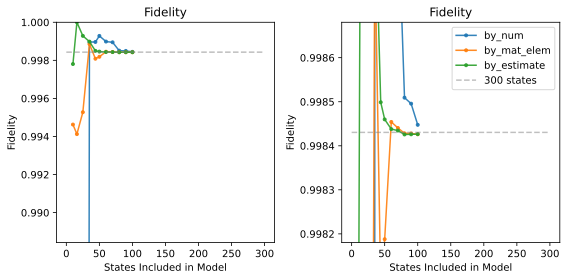

In [34]:
f, ax = plt.subplots(ncols=2, figsize=(8,4))
for estimate in ["by_num", "by_mat_elem", "by_estimate"]:
    ax[0].plot(first_n_states, 1-10**(np.array(fid["theta"][estimate])), label=estimate, marker=".", alpha=0.9)
    ax[1].plot(first_n_states, 1-10**(np.array(fid["theta"][estimate])), label=estimate, marker=".", alpha=0.9)

for i in range(2):
    ax[i].hlines(1-10**(f_300_theta), 0, 300, color="gray", label="300 states", linestyles="--", alpha=0.5)
    ax[i].set_title("Fidelity")
    ax[i].set_ylabel("Fidelity")
    ax[i].set_xlabel("States Included in Model")
# plt.yscale("log")
ax[1].set_ylim(1-10**(f_300_theta)-0.00025, 1-10**(f_300_theta)+0.00025)
ax[0].set_ylim(1-10**(f_300_theta)-0.01, 1)
plt.tight_layout()
plt.legend();

## $n_\phi$

In [ ]:
def phi_test_pulse(hilbert_space):
    tg_mod, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A = [2.4817536489456793, 0.02755483304039716, 0.047044443096421404, 0.01595110143999065, 0.01736804591088877, 0.0]
    tg_base = 500
    tg = tg_base+tg_mod
    n_cpu = 2
    argz = [H0, drive_term["phi"], w_trans_1["phi"], w_trans_2["phi"], hilbert_space, n_cpu, tg,
            drive_amp_A, drive_amp_B, detune_A, detune_B, 0, 0]
    return ut.xgate_fidelity_fast(argz)

f_300_phi = phi_test_pulse(list(np.arange(300)))
f_300_phi

In [43]:
first_n_states = [10, 16, 25, 35, 44, 50, 60, 70, 80, 90, 100]
first_n_states = first_n_states

drive = "phi"
    
fid[drive] = {}
fid[drive]["by_num"] = []
fid[drive]["by_mat_elem"] = []
fid[drive]["by_estimate"] = []

states[drive] = {}
states[drive]["by_num"] = []
states[drive]["by_mat_elem"] = []
states[drive]["by_estimate"] = []

order_charge_wo_firsts[drive] = [x for x in order_to_keep[drive] if x not in first_leak[drive] and x not in core_states[drive]]

for n in tqdm(first_n_states):
    states[drive]["by_num"].append(list(np.arange(n)))
    fid[drive]["by_num"].append(phi_test_pulse(states[drive]["by_num"][-1]))
    states[drive]["by_mat_elem"].append(sorted(set(core_states[drive] + order_charge[drive][:n])))
    fid[drive]["by_mat_elem"].append(phi_test_pulse(states[drive]["by_mat_elem"][-1]))
    states[drive]["by_estimate"].append(sorted(set(core_states[drive] + first_leak[drive] + order_charge_wo_firsts[drive][:n-len(first_leak[drive])])))
    fid[drive]["by_estimate"].append(phi_test_pulse(states[drive]["by_estimate"][-1]))

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [16:08<00:00, 88.04s/it] 


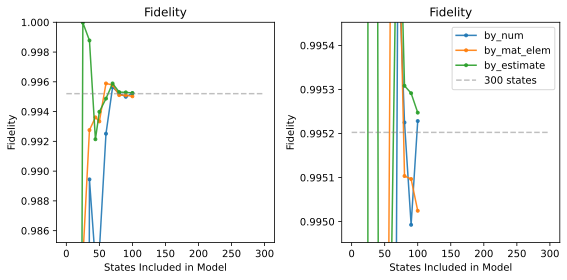

In [46]:
f, ax = plt.subplots(ncols=2, figsize=(8,4))
for estimate in ["by_num", "by_mat_elem", "by_estimate"]:
    ax[0].plot(first_n_states, 1-10**(np.array(fid["phi"][estimate])), label=estimate, marker=".", alpha=0.9)
    ax[1].plot(first_n_states, 1-10**(np.array(fid["phi"][estimate])), label=estimate, marker=".", alpha=0.9)

for i in range(2):
    ax[i].hlines(1-10**(f_300_phi), 0, 300, color="gray", label="300 states", linestyles="--", alpha=0.5)
    ax[i].set_title("Fidelity")
    ax[i].set_ylabel("Fidelity")
    ax[i].set_xlabel("States Included in Model")
# plt.yscale("log")
ax[1].set_ylim(1-10**(f_300_phi)-0.00025, 1-10**(f_300_phi)+0.00025)
ax[0].set_ylim(1-10**(f_300_phi)-0.01, 1)
plt.tight_layout()
plt.legend();

This pulse was optimized for that high green data point, so maybe it's not a great choice of test pulse